In [5]:
from pydriveless import SearchFrame, angle
from ensemble import PhysicalParameters
import numpy as np
import cv2
import matplotlib.pyplot as plt



/usr/local/lib/python3.10/dist-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/usr/local/lib/python3.10/dist-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/usr/local/lib/python3.10/dist-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/usr/local/lib/python3.10/dist-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


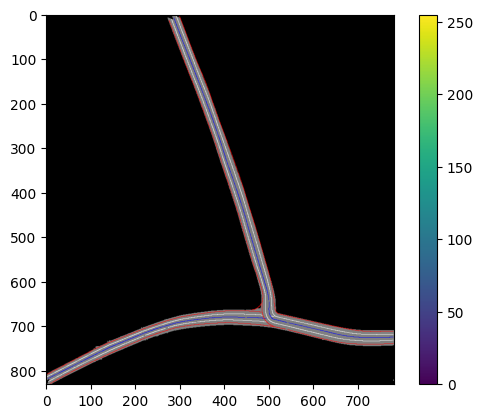

In [6]:
img = np.array(cv2.imread("converted_bev_23.png"), dtype=np.float32)

COSTS = np.array([-1, 0, 0, 0, 0])
COLORS = np.array([
            [0, 0, 0],
            [128, 128, 128],
            [0, 0, 255],
            [255, 255, 255],
            [255, 0, 0]
        ])

frame = SearchFrame (
    width=img.shape[1],
    height=img.shape[0],
    lower_bound=(-1, -1),
    upper_bound=(-1, -1))
    
frame.set_class_costs(COSTS)
frame.set_class_colors(COLORS)
frame.set_frame_data(img)

plt.imshow(frame.get_color_frame())
plt.colorbar()
plt.show()


Preprocessing of Search Space for Collision

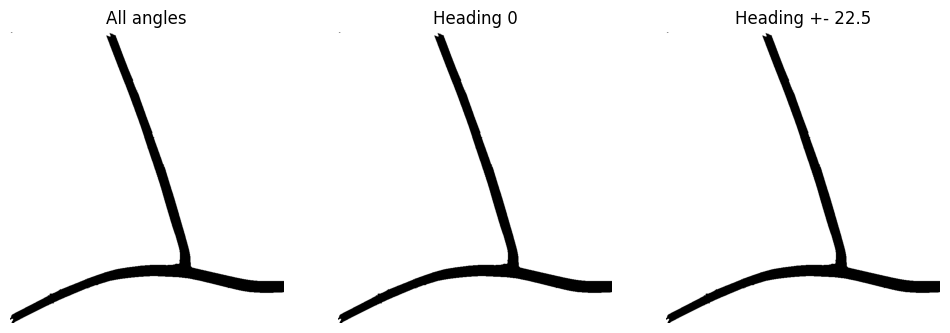

In [7]:
frame.process_safe_distance_zone((2, 2), True)
frame.process_distance_to_goal(107, 0)

f = frame.get_frame()
fp_all = np.zeros(f.shape, dtype=np.uint8)
fp_zero = np.zeros(f.shape, dtype=np.uint8)
fp_22 = np.zeros(f.shape, dtype=np.uint8)

for z in range(f.shape[0]):
    for x in range(f.shape[1]):
        if int(f[z, x, 2]) == 0x00:
            fp_all[z, x, :] = [255, 255, 255]
            fp_zero[z, x, :] = [255, 255, 255]
            fp_22[z, x, :] = [255, 255, 255]
            continue
        if (int(f[z, x, 2]) & 0x04) <= 0 and (int(f[z, x, 2]) & 0x10) <= 0:
            fp_22[z, x, :] = [128, 128, 128]

        if (int(f[z, x, 2]) & 0x08) <= 0:
            fp_zero[z, x, :] = [128, 128, 128]
                        
        if (int(f[z, x, 2]) & 0x100) <= 0:
            fp_all[z, x, :] = [128, 128, 128]
            


fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(fp_all)
axes[0].set_title("All angles")
axes[0].axis("off")

axes[1].imshow(fp_zero)
axes[1].set_title("Heading 0")
axes[1].axis("off")

axes[2].imshow(fp_22)
axes[2].set_title("Heading +- 22.5")
axes[2].axis("off")

plt.show()


False


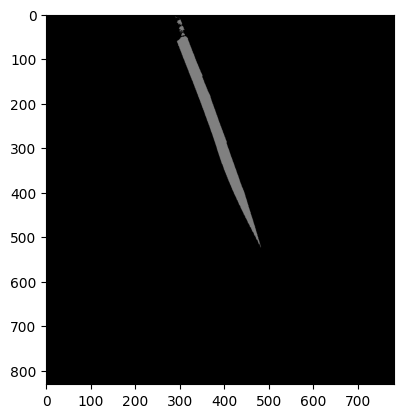

In [8]:
from pyfastrrt import CudaGraph

graph = CudaGraph(
    width=img.shape[1],
    height=img.shape[0],
    perception_width_m=PhysicalParameters.OG_REAL_WIDTH,
    perception_height_m=PhysicalParameters.OG_REAL_HEIGHT,
    lower_bound_x=-1,
    lower_bound_z=-1,
    upper_bound_x=-1,
    upper_bound_z=-1,
    max_steering_angle_deg=PhysicalParameters.MAX_STEERING_ANGLE,
    vehicle_length_m=PhysicalParameters.VEHICLE_LENGTH_M,
    path_costs=COSTS,
    min_dist_x=2,
    min_dist_z=2,
)

start = (416, 686, angle.new_deg(90 + -0.039754376).rad())
goal = (308, 49, angle.new_deg(-8.9513413283239596).rad())

graph.add(start[0], start[1], angle.new_rad(start[2]), -1, -1, 0)

graph.process_direct_goal_connection(frame, goal[0], goal[1], angle.new_rad(goal[2]), max_curvature=3.8)

f = np.zeros(shape=(frame.height(), frame.width(), 3), dtype=np.uint8)
#f = frame.get_color_frame()
for z in range(frame.height()):
    for x in range(frame.width()):
        if graph.is_directly_connected_to_goal(x, z):
            f[z, x, :] = [128, 128, 128]

plt.imshow(f)
        

print( graph.is_directly_connected_to_goal(128, 128))

Node (416, 686) is NOT directly connected to goal


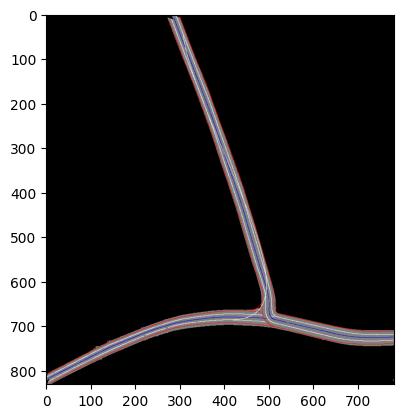

In [9]:
from hermite import HermiteCurve

points = HermiteCurve.interpolate(
    width=frame.width(), 
    height=frame.height(),
    p1=start,
    p2=goal,
    max_curvature=0.26)

f = frame.get_color_frame()

for p in points:
    f[p[1], p[0]] = [255, 255, 255]

plt.imshow(f)

if (graph.is_directly_connected_to_goal(start[0], start[1])):
    heading = graph.direct_connection_to_goal_heading(start[0], start[1])
    cost = graph.direct_connection_to_goal_cost(start[0], start[1])
    print(f"Node {start[0], start[1]} is directly connected to goal with heading = {heading.deg():.2f} deg and cost = {cost:.2f}")
else:
    print(f"Node {start[0], start[1]} is NOT directly connected to goal")

Analise das paths obtidas pela execução do FastRRT

In [10]:
import numpy as np
coarse = np.load("coarse_path.npy")

[[ 4.1600000e+02  6.8600000e+02  1.5701026e+00]
 [ 4.5300000e+02  6.8200000e+02  1.3607186e+00]
 [ 4.5900000e+02  6.7900000e+02  1.0553770e+00]
 [ 4.7500000e+02  6.9000000e+02  2.8335340e+00]
 [ 4.8800000e+02  6.9500000e+02  1.5313594e+00]
 [ 5.0100000e+02  7.0000000e+02  2.1191261e+00]
 [ 5.1000000e+02  6.9400000e+02  6.1382997e-01]
 [ 5.1200000e+02  6.8900000e+02  4.7724071e-01]
 [ 5.1300000e+02  6.8400000e+02  3.1327692e-01]
 [ 5.0800000e+02  6.5400000e+02 -5.0010967e-01]
 [ 2.9600000e+02  1.5000000e+01 -2.4434610e-01]]


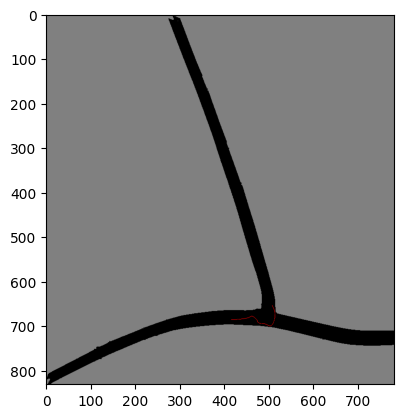

In [19]:
f = frame.get_frame()
fc = np.zeros(f.shape, dtype=np.uint8)

for z in range(f.shape[0]):
    for x in range(f.shape[1]):
        if (f[z, x, 2] == 0.0):
            fc[z, x, :] = [128, 128, 128]
        
print(coarse)

p1 = None
p2 = None
for p in coarse[0:-1]:
    p1 = p2    
    p2 = p
    if p1 is None: continue
        
    sub_path = HermiteCurve.interpolate(
        width=f.shape[1],
        height=f.shape[1],
        p1=p1,
        p2=p2,
        max_curvature=-1
    )

    for sp in sub_path:
        fc[int(sp[1]), int(sp[0]), :] = [255, 0, 0]

plt.imshow(fc)

In [20]:
graph.is_directly_connected_to_goal(508, 654)

False